In [1]:
import numpy as np
import pandas as pd
from obspy.core import read, UTCDateTime
from obspy.core.inventory import read_inventory
from obspy.core.util.attribdict import AttribDict
from obspy.clients.fdsn import Client
from collections import defaultdict
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from obspy.taup import TauPyModel
import matplotlib.pyplot as plt
from pystp import STPClient
import json
import os
from obspy.core.stream import Stream

In [2]:
def to_number(polarity):
    if polarity == 'positive':
        return 1
    elif polarity == 'negative':
        return -1
    else:
        return 0

In [3]:
stp = STPClient()
stp.connect()

	****************************************
	*   Welcome to the Southern California *
	*      Earthquake Data Center          *
	*     Seismic Transfer Program         *
        ****************************************

Please use the following citation:
 SCEDC (2013): Southern California Earthquake Data Center.
 Caltech.Dataset. doi:10.7909/C3WD3xH
to cite data downloaded from the SCEDC.

If you use a SCEDC waveform dataset that contains data with
network codes other than 'CI', please cite the network and
its DOI. Use https://fdsn.org/networks/ to find the network
code and its corresponding DOI.

For large downloads, please consider trying the SCEDC AWS Public Dataset:
https://scedc.caltech.edu/data/cloud.html




In [5]:
# read in json file 'success_case_study.json'
with open('success_case_study.json', 'r') as f:
    data = json.load(f)
keys = list(data.keys())
print(keys)

['PFO', 'CMB', 'CALB', 'GSC', 'ISA', 'MLAC', 'MLL', 'PAS', 'RPV', 'RUN', 'SBC', 'SBK', 'SVD', 'SWM', 'USC', 'VG2', 'VTV', 'WAS']


In [6]:
event_id = 3146815 # best from other code
event = stp.get_events(evids=[event_id]).events[0]
event

Event:	1994-01-28T07:44:46.295000Z | +34.233, -118.615 | 3.43 ML

	 resource_id: ResourceIdentifier(id="3146815")
	  event_type: 'earthquake'
	        ---------
	     origins: 1 Elements
	  magnitudes: 1 Elements

In [7]:
with open('all_wmd.json', 'r') as f:
    wmd_dict = json.load(f)

In [8]:
stations = wmd_dict[str(event_id)]
# filter out where network != CI
stations = [sta for sta in stations if sta[0] == 'CI']
# print(stations)
all_unique_stations = set()
for sta in stations:
    all_unique_stations.add(sta[1])
benchmark_stations = list(all_unique_stations)

In [9]:
origin = event.origins[0]
origin_time = origin.time
lat = origin.latitude
lon = origin.longitude
depth = origin.depth
magnitude = event.magnitudes[0].mag
starttime = origin_time - 600
endtime = origin_time + 600

event_alt = stp.get_events(times=[starttime, endtime], mags=[magnitude-0.5, magnitude+0.5],
                           lats=[lat-1, lat+1], lons=[lon-1, lon+1]).events[0]
event_alt

Event:	1994-01-28T07:44:46.295000Z | +34.233, -118.615 | 3.43 ML

	 resource_id: ResourceIdentifier(id="3146815")
	  event_type: 'earthquake'
	        ---------
	     origins: 1 Elements
	  magnitudes: 1 Elements

In [10]:
phase_picks = stp.get_phases(evids=[event_id])[0].picks
phase_picks = [phase for phase in phase_picks if phase.phase_hint == 'P']
phase_picks

[Pick
	 resource_id: ResourceIdentifier(id="smi:local/7e3033e2-44e9-4405-b2dd-f8f393ac789c")
	        time: UTCDateTime(1994, 1, 28, 7, 44, 49, 536000) [upper_uncertainty=0.0]
	 waveform_id: WaveformStreamID(network_code='ZY', station_code='CPCP', channel_code='EHZ', location_code='--')
	       onset: 'impulsive'
	  phase_hint: 'P'
	    polarity: 'negative',
 Pick
	 resource_id: ResourceIdentifier(id="smi:local/8491779c-d440-4f32-bd12-d01e936d48e9")
	        time: UTCDateTime(1994, 1, 28, 7, 44, 52, 365000) [upper_uncertainty=0.01]
	 waveform_id: WaveformStreamID(network_code='ZY', station_code='CWHP', channel_code='EHZ', location_code='--')
	       onset: 'impulsive'
	  phase_hint: 'P'
	    polarity: 'positive',
 Pick
	 resource_id: ResourceIdentifier(id="smi:local/478d4ab8-4f20-4199-8789-bc7c938b8dcc")
	        time: UTCDateTime(1994, 1, 28, 7, 44, 49, 570000) [upper_uncertainty=0.01]
	 waveform_id: WaveformStreamID(network_code='CI', station_code='TWL', channel_code='EHZ', location_

In [11]:
phase_picks_pol = [phase for phase in phase_picks if phase.polarity is not None]
phase_picks_pol

[Pick
	 resource_id: ResourceIdentifier(id="smi:local/7e3033e2-44e9-4405-b2dd-f8f393ac789c")
	        time: UTCDateTime(1994, 1, 28, 7, 44, 49, 536000) [upper_uncertainty=0.0]
	 waveform_id: WaveformStreamID(network_code='ZY', station_code='CPCP', channel_code='EHZ', location_code='--')
	       onset: 'impulsive'
	  phase_hint: 'P'
	    polarity: 'negative',
 Pick
	 resource_id: ResourceIdentifier(id="smi:local/8491779c-d440-4f32-bd12-d01e936d48e9")
	        time: UTCDateTime(1994, 1, 28, 7, 44, 52, 365000) [upper_uncertainty=0.01]
	 waveform_id: WaveformStreamID(network_code='ZY', station_code='CWHP', channel_code='EHZ', location_code='--')
	       onset: 'impulsive'
	  phase_hint: 'P'
	    polarity: 'positive',
 Pick
	 resource_id: ResourceIdentifier(id="smi:local/478d4ab8-4f20-4199-8789-bc7c938b8dcc")
	        time: UTCDateTime(1994, 1, 28, 7, 44, 49, 570000) [upper_uncertainty=0.01]
	 waveform_id: WaveformStreamID(network_code='CI', station_code='TWL', channel_code='EHZ', location_

In [22]:
len(phase_picks_pol)

99

In [23]:
phase_picks_pol_CI = [phase for phase in phase_picks_pol if phase.waveform_id.network_code == 'CI']
len(phase_picks_pol_CI)

77

In [24]:
# origin = event.origins[0]
# origin_time = origin.time
# lat = origin.latitude
# lon = origin.longitude
# magnitude = event.magnitudes[0].mag
# starttime = origin_time - 600
# endtime = origin_time + 600

In [25]:
# come on... what are we doing here?

In [26]:
# create a dictionary that stores sign for each station
data_dict = defaultdict(list)
client = Client("SCEDC")

for idx, pick in enumerate(phase_picks_pol_CI):
    if idx % 10 == 0:
        print(f"Processing pick {idx}/{len(phase_picks_pol_CI)}")
    stat = pick.waveform_id.station_code
    net = pick.waveform_id.network_code
    chan = pick.waveform_id.channel_code
    loc = pick.waveform_id.location_code
    loc = loc if loc != '--' else ''
    seed_id = '.'.join([net, stat, loc, chan])
    try:
        inv = client.get_stations(network=net, station=stat, location=loc, channel=chan,
                              starttime=starttime, endtime=endtime, level="response")
    except:
        print(f"Failed to get station info for {seed_id}")
        # break
        continue
    
    try:
        coordinates = inv.get_coordinates(seed_id)
    except:
        print(f"Failed to get coordinates for {seed_id}")
        # break
        continue
    if len(data_dict[seed_id]) == 0:
            data_dict[seed_id].extend(list(coordinates.values())[:2] + [to_number(pick.polarity)])
    # break
data_dict

Processing pick 0/77
Processing pick 10/77
Processing pick 20/77
Processing pick 30/77
Processing pick 40/77
Processing pick 50/77
Processing pick 60/77
Processing pick 70/77


defaultdict(list,
            {'CI.TWL..EHZ': [34.27827, -118.59548, 1],
             'CI.GRH..EHZ': [34.30803, -118.55954, 1],
             'CI.SIP..EHZ': [34.20453, -118.78073, 1],
             'CI.SAD..EHZ': [34.08087, -118.66554, -1],
             'CI.NHL..EHZ': [34.39148, -118.59946, -1],
             'CI.SYL..EHZ': [34.3536, -118.45098, -1],
             'CI.SCY..EHZ': [34.10647, -118.45533, 1],
             'CI.OAK..EHZ': [34.36363, -118.78439, 1],
             'CI.IR2..EHZ': [34.38807, -118.39972, -1],
             'CI.SMF..EHZ': [34.02159, -118.44675, -1],
             'CI.FIL..EHZ': [34.42335, -118.83531, 1],
             'CI.GFP..ELZ': [34.13165, -118.31978, -1],
             'CI.VRD..EHZ': [34.21459, -118.27964, -1],
             'CI.PTD..EHZ': [34.00443, -118.80686, -1],
             'CI.WSP..EHZ': [34.59618, -118.57972, -1],
             'CI.PAS..EHZ': [34.14844, -118.17117, -1],
             'CI.SLG..EHZ': [34.10946, -119.06496, -1],
             'CI.GSA..ELZ': [34.13677

In [27]:
inv = client.get_stations(network=net, station=stat, location=loc, channel=chan,
                              starttime=starttime, endtime=endtime, level="response")
coordinates = inv.get_coordinates(seed_id)
coordinates

{'latitude': 35.94896,
 'longitude': -117.64787,
 'elevation': 930.0,
 'local_depth': 0.0}

In [28]:
# origin = event.origins[0]
# origin_time = origin.time
# lat = origin.latitude
# lon = origin.longitude
# depth = origin.depth
# magnitude = event.magnitudes[0].mag
# starttime = origin_time - 600
# endtime = origin_time + 600

In [31]:
# collapse to sign
for seed_id in data_dict:
    if abs(data_dict[seed_id][2]) > 1: print(f"{seed_id} has polarity {data_dict[seed_id][2]}")
    data_dict[seed_id][2] = np.sign(data_dict[seed_id][2])
# NOTE: get event location
lat = lat
lon = lon
hdepth = depth

col_string = 'event_id, station, network, location, channel, p_polarity, takeoff, takeoff_uncertainty, azimuth, azimuth_uncertainty'
columns = [col.strip() for col in col_string.split(',')]
df = pd.DataFrame(columns=columns)
df_phase = pd.DataFrame(columns=['phase'])
event_id = event_id
takeoff_unc = 0.1 # placeholder
az_unc = 0.1 # placeholder
epdists = []
 
velocity_model = TauPyModel(model='ak135')
# velocity_model = TauPyModel(model='iasp91')

for key, value in data_dict.items():
    net, stat, loc, chan = key.split('.')
    p_polarity = value[2]
    src2dst = [lat, lon, value[0], value[1]]
    dist, az, baz = gps2dist_azimuth(*src2dst)
    epdist = kilometers2degrees(dist / 1000) # convert to km
    
    try:
        print()
        print(f"INPUTS:\n{hdepth} km depth, {epdist:.2f} degrees epdist for station {stat}")
        p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                            distance_in_degree=epdist, phase_list=['P', 'p'])
                            # phase_list=['P', 'Pn', 'Pg'])
        print(f"OUTPUTS:")
        for arrival in p_arrivals:
            print(f"Phase: {arrival.phase.name}, Time: {arrival.time:.2f} s, Takeoff angle: {arrival.takeoff_angle:.2f} degrees")
        print()
    except Exception as e:
        print(f"Error occurred while calculating travel times for station {stat}")
        # print error message
        print(f"Error: {e}")
        continue
    
    if len(p_arrivals) == 0:
        print(f"Station {stat} has no P arrival. Skipping.")
        print(f"Epidist = {epdist:.2f} degrees, depth = {hdepth} km")
        continue
    
    epdists.append(epdist)
    # pick min arrival time P wave
    min_arrival = min(p_arrivals, key=lambda x: x.time)
    takeoff = min_arrival.takeoff_angle
    takeoff = 180 - takeoff # convert to angle from vertical (SKHASH convention)
    
    if p_polarity != 0:
        df.loc[len(df)] = [event_id, stat, net, loc, chan, float(p_polarity),
                        takeoff, takeoff_unc, az, az_unc]
        name = 0 if min_arrival.phase.name == 'p' else 1
        df_phase.loc[len(df_phase)] = [name]
    else: print(f"Station {stat} has zero polarity. Skipping.")


INPUTS:
20.53 km depth, 0.05 degrees epdist for station TWL
OUTPUTS:
Phase: p, Time: 3.65 s, Takeoff angle: 163.68 degrees


INPUTS:
20.53 km depth, 0.09 degrees epdist for station GRH
OUTPUTS:
Phase: p, Time: 3.91 s, Takeoff angle: 151.32 degrees


INPUTS:
20.53 km depth, 0.14 degrees epdist for station SIP
OUTPUTS:
Phase: p, Time: 4.43 s, Takeoff angle: 137.47 degrees


INPUTS:
20.53 km depth, 0.16 degrees epdist for station SAD
OUTPUTS:
Phase: p, Time: 4.64 s, Takeoff angle: 133.53 degrees


INPUTS:
20.53 km depth, 0.16 degrees epdist for station NHL
OUTPUTS:
Phase: p, Time: 4.65 s, Takeoff angle: 133.27 degrees


INPUTS:
20.53 km depth, 0.18 degrees epdist for station SYL
OUTPUTS:
Phase: p, Time: 4.94 s, Takeoff angle: 128.45 degrees


INPUTS:
20.53 km depth, 0.18 degrees epdist for station SCY
OUTPUTS:
Phase: p, Time: 4.96 s, Takeoff angle: 128.15 degrees


INPUTS:
20.53 km depth, 0.19 degrees epdist for station OAK
OUTPUTS:
Phase: p, Time: 5.08 s, Takeoff angle: 126.47 degrees



In [66]:
min_arrival.phase.name

'P'

In [1]:
18.96/0.0253

749.407114624506

In [30]:
df.to_csv(f'pol_{event_id}.csv', index=False)
df_phase.to_csv(f'pol_phases_{event_id}.csv', index=False)

In [136]:
# look at the channels used to determine the picks
pick_channels = set()
for pick in phase_picks:
    pick_channels.add(pick.waveform_id.channel_code)
pick_channels

{'EHZ', 'ELN', 'ELZ', 'HHZ'}

In [137]:
test = data[keys[10]]
test

[['CI', 'SBC', 'BHN', '--', 'T', 'A', '1994/01/28,07:43:41.275', '5.15m'],
 ['CI', 'SBC', 'BHZ', '--', 'T', 'A', '1994/01/28,07:44:19.025', '5.19m']]

In [138]:
# filtered_benchmarks = []
# for station in benchmark_stations:
#     try:
#         streams = stp.get_trig(event_id, net='CI', sta=station)
#     except:
#         continue
#     if len(streams[event_id]) != 0:
#         filtered_benchmarks.append(station)
# print(filtered_benchmarks)

filtered_benchmarks = ['GSC', 'PAS', 'MLAC', 'SBC', 'ISA', 'VTV', 'RPV', 'SVD', 'USC']

In [139]:
combo_benchmark = list(set(filtered_benchmarks) & set(keys))
assert len(combo_benchmark) == len(filtered_benchmarks) # samee process
print(combo_benchmark)

# get what's outside the combo benckmark
outside_benchmark = list(set(keys) - set(combo_benchmark))
print(outside_benchmark)

['ISA', 'VTV', 'RPV', 'GSC', 'PAS', 'MLAC', 'SVD', 'USC', 'SBC']
['VG2', 'CMB', 'SBK', 'SWM', 'RUN', 'PFO', 'MLL', 'CALB', 'WAS']


In [140]:
combo_sizes = {key: len(data[key]) for key in combo_benchmark}
combo_data = {key: data[key] for key in combo_benchmark}
outside_sizes = {key: len(data[key]) for key in outside_benchmark}
outside_data = {key: data[key] for key in outside_benchmark}
combo_sizes

{'ISA': 3,
 'VTV': 5,
 'RPV': 5,
 'GSC': 3,
 'PAS': 3,
 'MLAC': 5,
 'SVD': 2,
 'USC': 5,
 'SBC': 2}

In [155]:
stream_dict = {}
for key in combo_benchmark:
    streams = stp.get_trig(event_id, net='CI', sta=key)
    final_stream = Stream()
    for tr in streams[event_id]:
        if tr.stats.channel[0] == 'B': # only keep broadband channels
            final_stream.append(tr)
    stream_dict[key] = final_stream
stream_dict

Processed 3 waveform traces
Processed 6 waveform traces
Processed 6 waveform traces
Processed 3 waveform traces
Processed 3 waveform traces
Processed 6 waveform traces
Processed 3 waveform traces
Processed 6 waveform traces
Processed 3 waveform traces


{'ISA': 3 Trace(s) in Stream:
CI.ISA..BHE | 1994-01-28T07:42:34.815004Z - 1994-01-28T07:50:51.265004Z | 20.0 Hz, 9930 samples
CI.ISA..BHN | 1994-01-28T07:44:19.467001Z - 1994-01-28T07:49:33.317001Z | 20.0 Hz, 6278 samples
CI.ISA..BHZ | 1994-01-28T07:44:33.317000Z - 1994-01-28T07:49:48.667000Z | 20.0 Hz, 6308 samples,
 'VTV': 3 Trace(s) in Stream:
CI.VTV..BHE | 1994-01-28T07:43:03.917002Z - 1994-01-28T07:49:42.667002Z | 20.0 Hz, 7976 samples
CI.VTV..BHN | 1994-01-28T07:44:04.417002Z - 1994-01-28T07:49:03.617002Z | 20.0 Hz, 5985 samples
CI.VTV..BHZ | 1994-01-28T07:44:03.217001Z - 1994-01-28T07:49:15.967001Z | 20.0 Hz, 6256 samples,
 'RPV': 3 Trace(s) in Stream:
CI.RPV..BHE | 1994-01-28T07:43:21.642000Z - 1994-01-28T07:48:13.992000Z | 20.0 Hz, 5848 samples
CI.RPV..BHN | 1994-01-28T07:43:11.942003Z - 1994-01-28T07:48:12.592003Z | 20.0 Hz, 6014 samples
CI.RPV..BHZ | 1994-01-28T07:44:04.092001Z - 1994-01-28T07:47:48.842001Z | 20.0 Hz, 4496 samples,
 'GSC': 3 Trace(s) in Stream:
CI.GSC..BHE |

In [152]:
stream_dict['GSC'][0].stats.channel

         network: CI
         station: GSC
        location: 
         channel: BHE
       starttime: 1994-01-28T07:42:08.843996Z
         endtime: 1994-01-28T07:50:06.793996Z
   sampling_rate: 20.0
           delta: 0.05
            npts: 9560
           calib: 1.0
         _format: SAC
             sac: AttribDict({'delta': 0.05, 'depmin': -6675.0, 'depmax': 5528.0, 'b': -157.451, 'e': 320.499, 'o': 0.0, 'stla': 35.30177, 'stlo': -116.80574, 'stel': 1000.0, 'stdp': 0.0, 'evla': 34.233, 'evlo': -118.615, 'evdp': 20.532, 'mag': 3.43, 'dist': 203.68666, 'az': 53.889973, 'baz': 234.9218, 'gcarc': 1.8317981, 'depmen': -88.18358, 'cmpaz': 90.0, 'cmpinc': 90.0, 'nzyear': 1994, 'nzjday': 28, 'nzhour': 7, 'nzmin': 44, 'nzsec': 46, 'nzmsec': 295, 'nvhdr': 6, 'nevid': 3146815, 'npts': 9560, 'iftype': 1, 'idep': 5, 'imagtyp': 54, 'leven': 1, 'lpspol': 0, 'lcalda': 1, 'kstnm': 'GSC', 'khole': '', 'kcmpnm': 'BHE', 'knetwk': 'CI', 'kinst': 'BHE', 'kevnm': ''})

In [156]:
# save stream_dict as a pickle file
import pickle
with open(f'streams_{event_id}.pkl', 'wb') as f:
    pickle.dump(stream_dict, f)

Processed 6 waveform traces


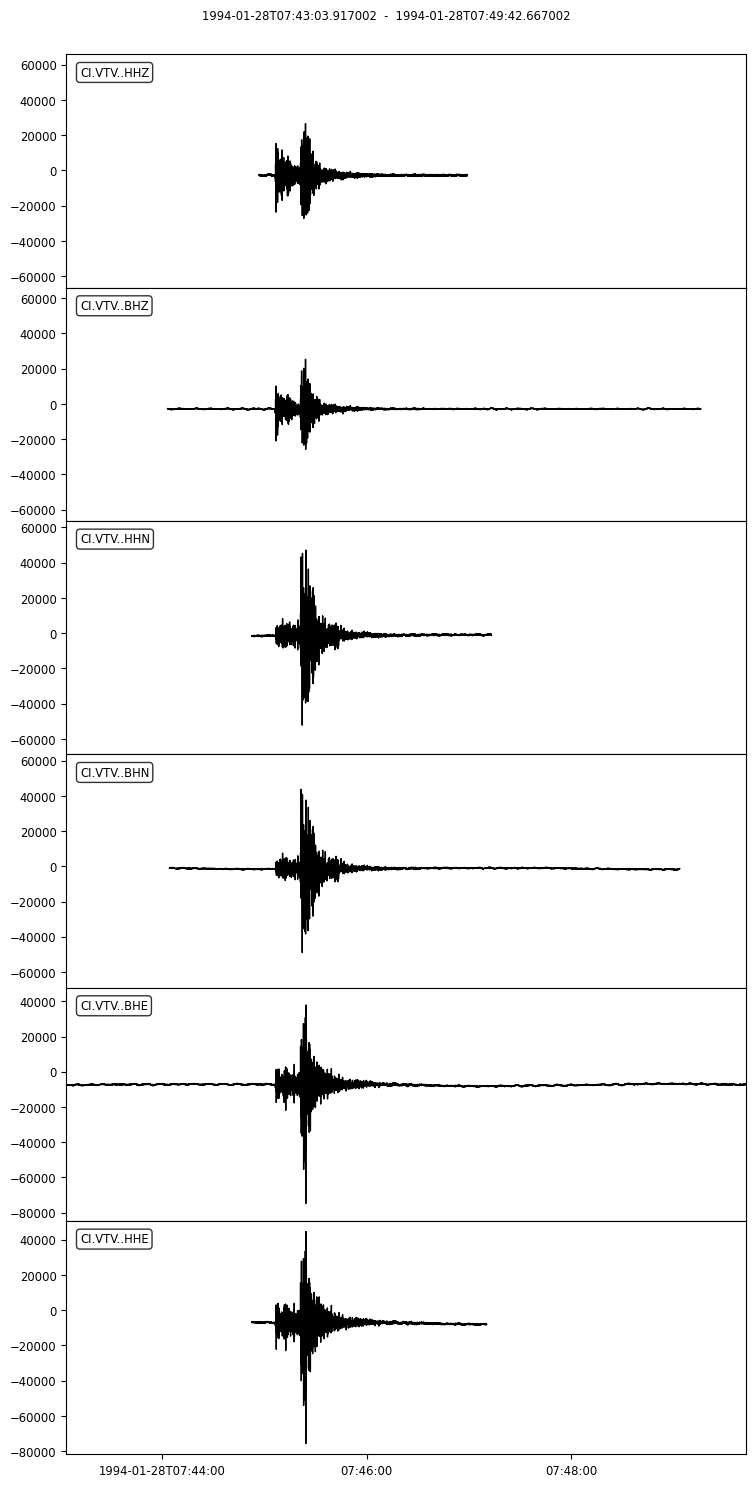

In [141]:
# get waveforms at the based on the average pick time in test using get_window
# compare results with get_trig for one, then make decision on teleseismic vs local/regional
# starttime = time - 5 min
# endtime = time + 5 min

streams = stp.get_trig(event_id, net='CI', sta=combo_benchmark[1])
streams[event_id].plot();

# now extract amplitudes just like before

# remove response

In [142]:
starttime = streams[event_id][1].stats.starttime
endtime = streams[event_id][1].stats.endtime

# 1994-01-28T07:43:03.917002Z - 1994-01-28T07:49:42.667002Z

In [143]:
client = Client("SCEDC")
inv = client.get_stations(network="CI", station=combo_benchmark[1],
                          starttime=starttime, endtime=endtime,
                          level="response")
inv

Inventory created at 2026-06-09T18:34:17.000000Z
	Created by: SCEDC WEB SERVICE: fdsnws-station | version: 1.1
		    http://service.scedc.caltech.edu/fdsnws/station/1/query?net=CI&sta=...
	Sending institution: SCEDC (SCEDC)
	Contains:
		Networks (1):
			CI
		Stations (1):
			CI.VTV (Victorville)
		Channels (21):
			CI.VTV..BHZ, CI.VTV..BHN, CI.VTV..BHE, CI.VTV..HHZ, CI.VTV..HHN, 
			CI.VTV..HHE, CI.VTV..HLZ, CI.VTV..HLN, CI.VTV..HLE, CI.VTV..LHZ, 
			CI.VTV..LHN, CI.VTV..LHE, CI.VTV..LLZ, CI.VTV..LLN, CI.VTV..LLE, 
			CI.VTV..VHZ, CI.VTV..VHN, CI.VTV..VHE, CI.VTV..VMZ, CI.VTV..VMN, 
			CI.VTV..VME

In [ ]:
# from all these stations, get the overlapping channel data. B? H?

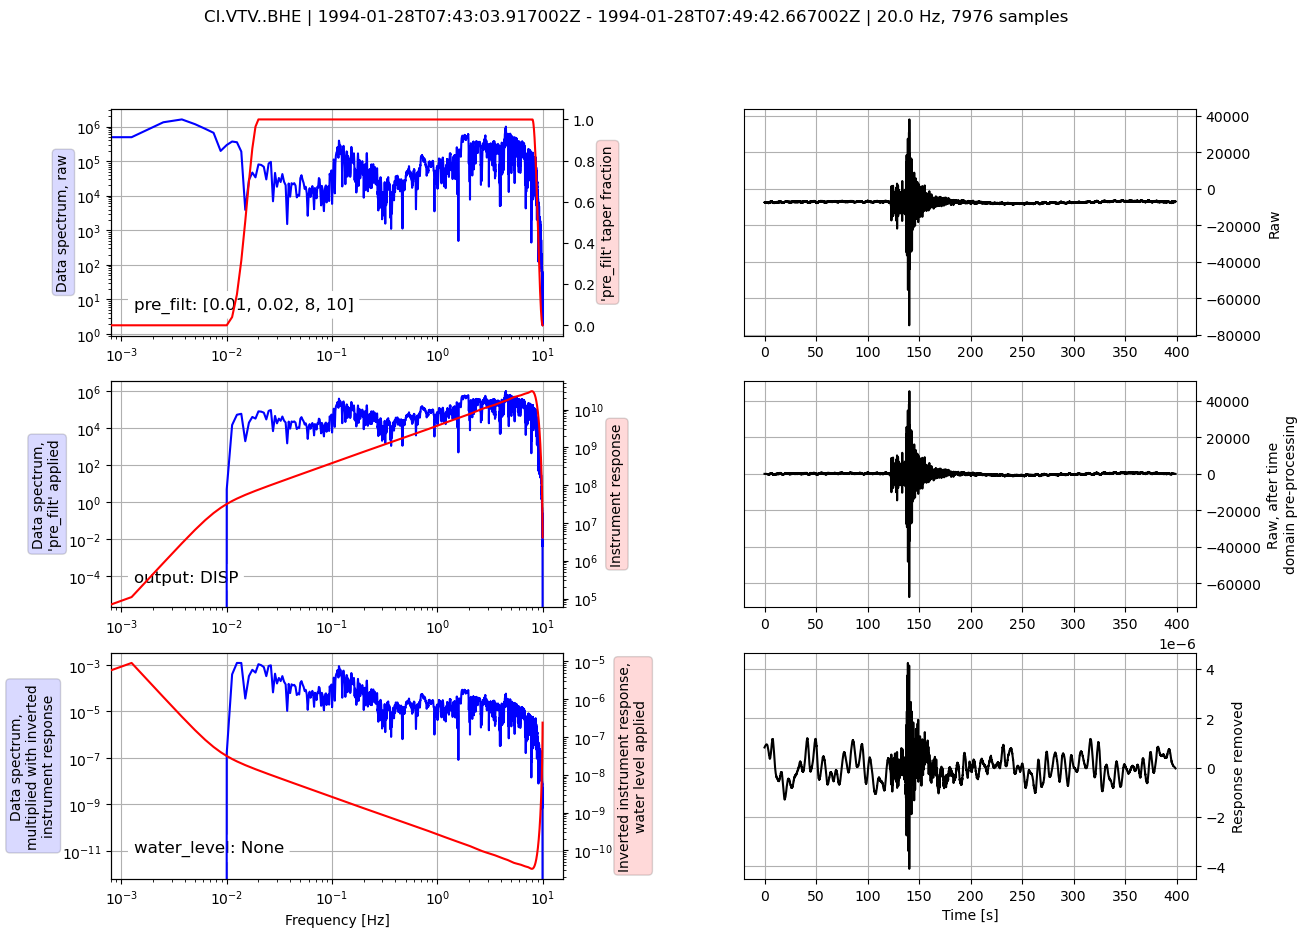

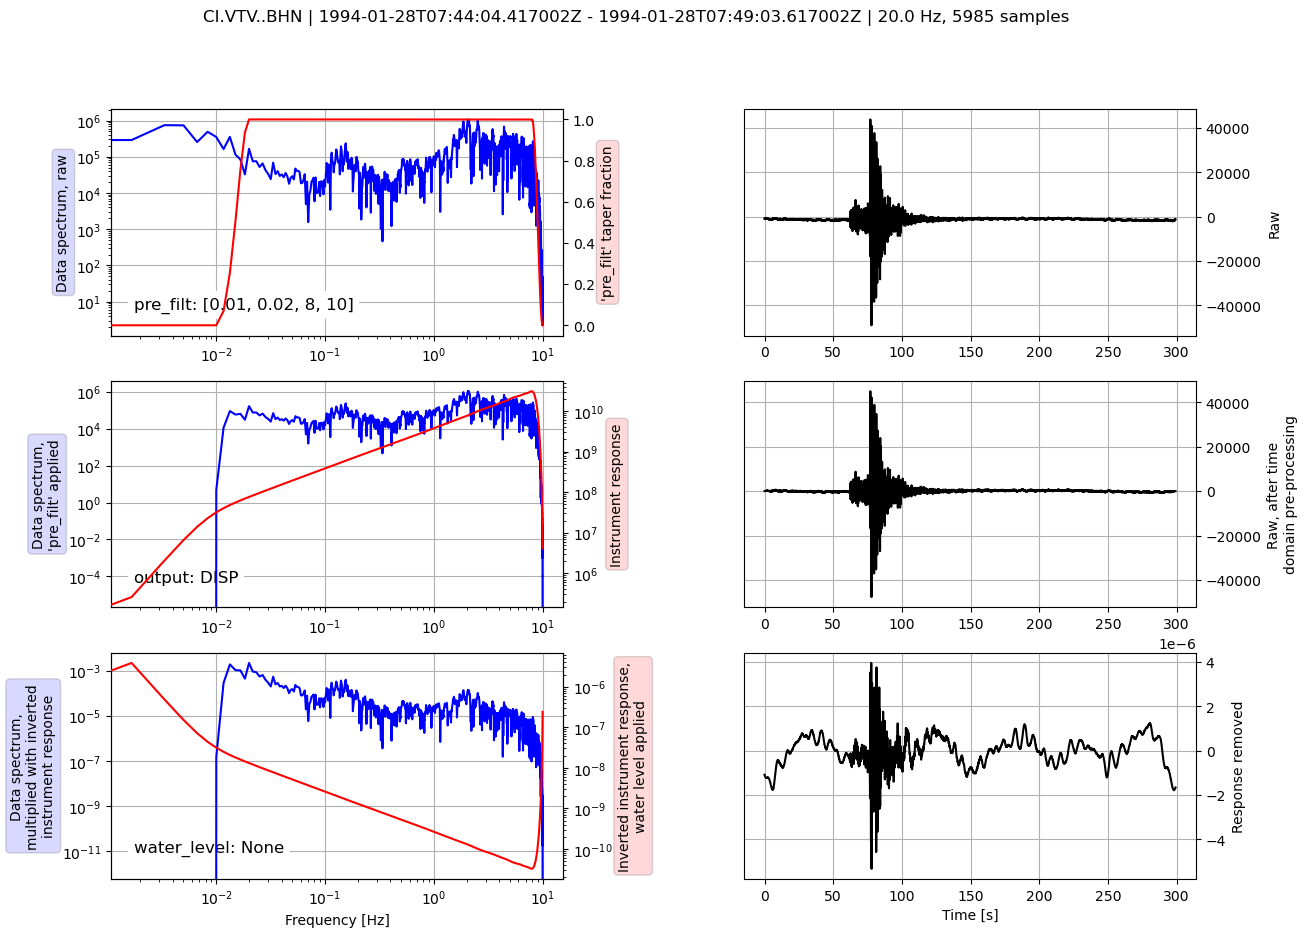

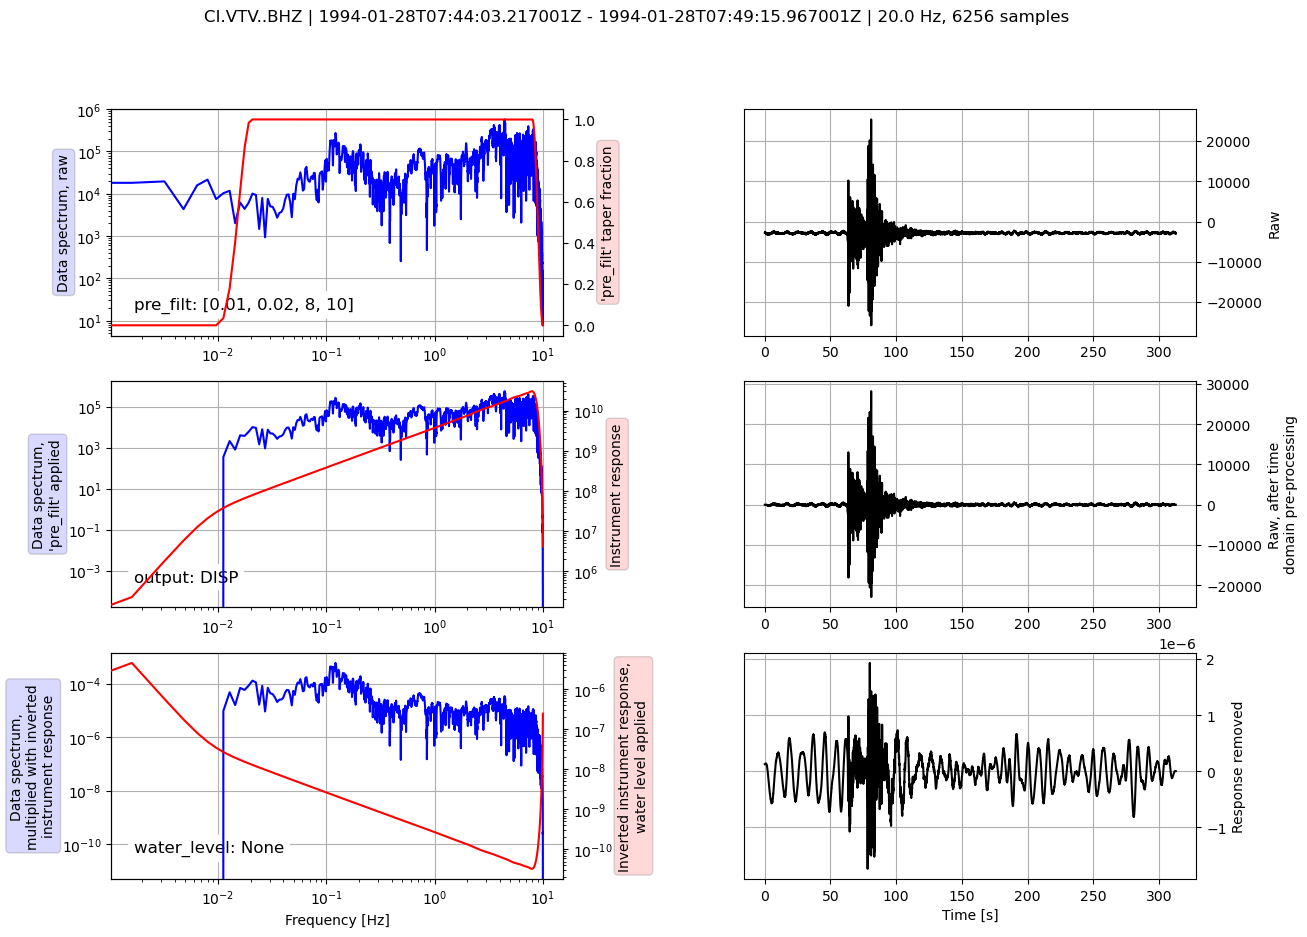

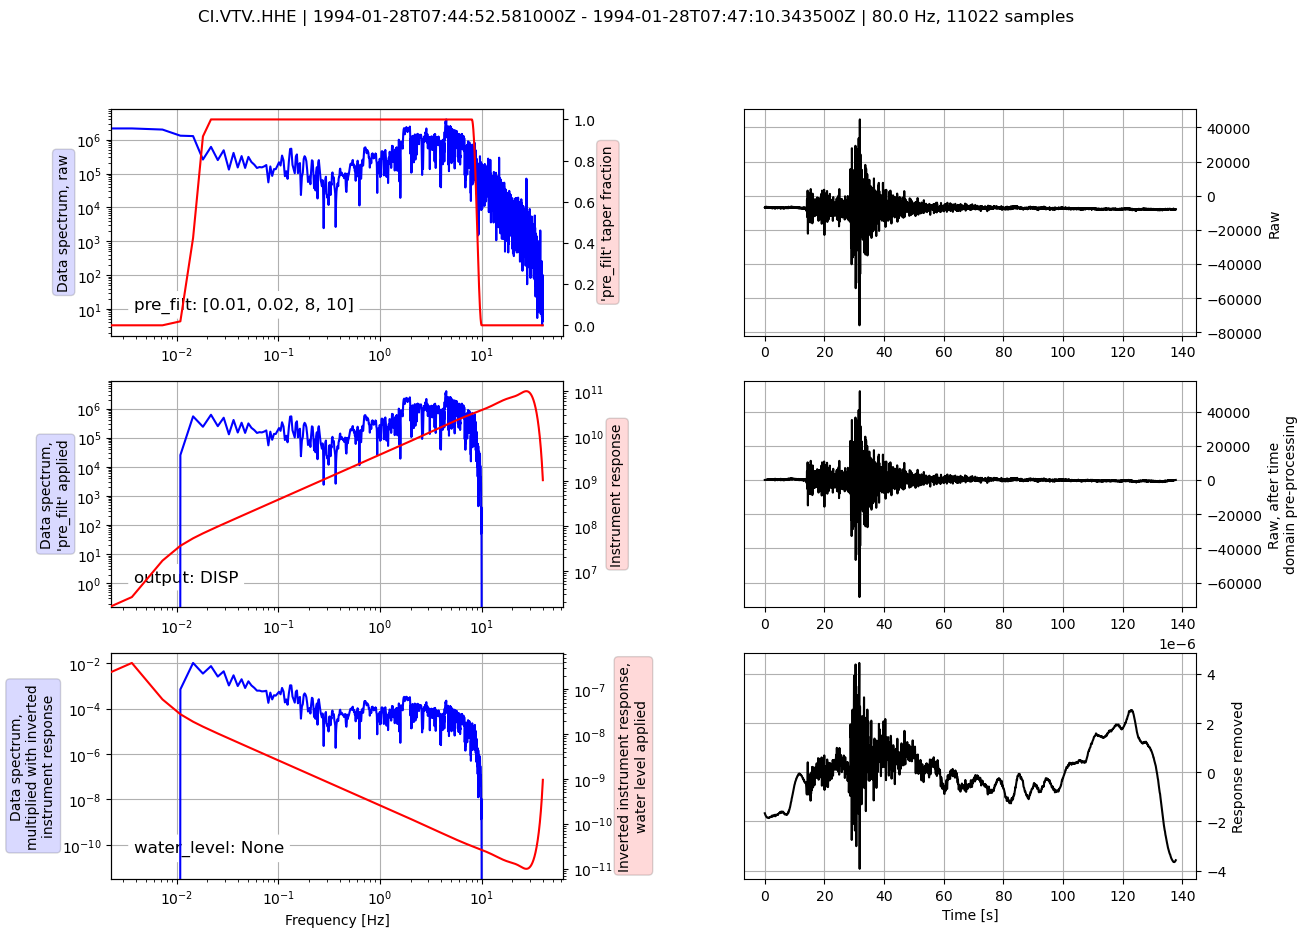

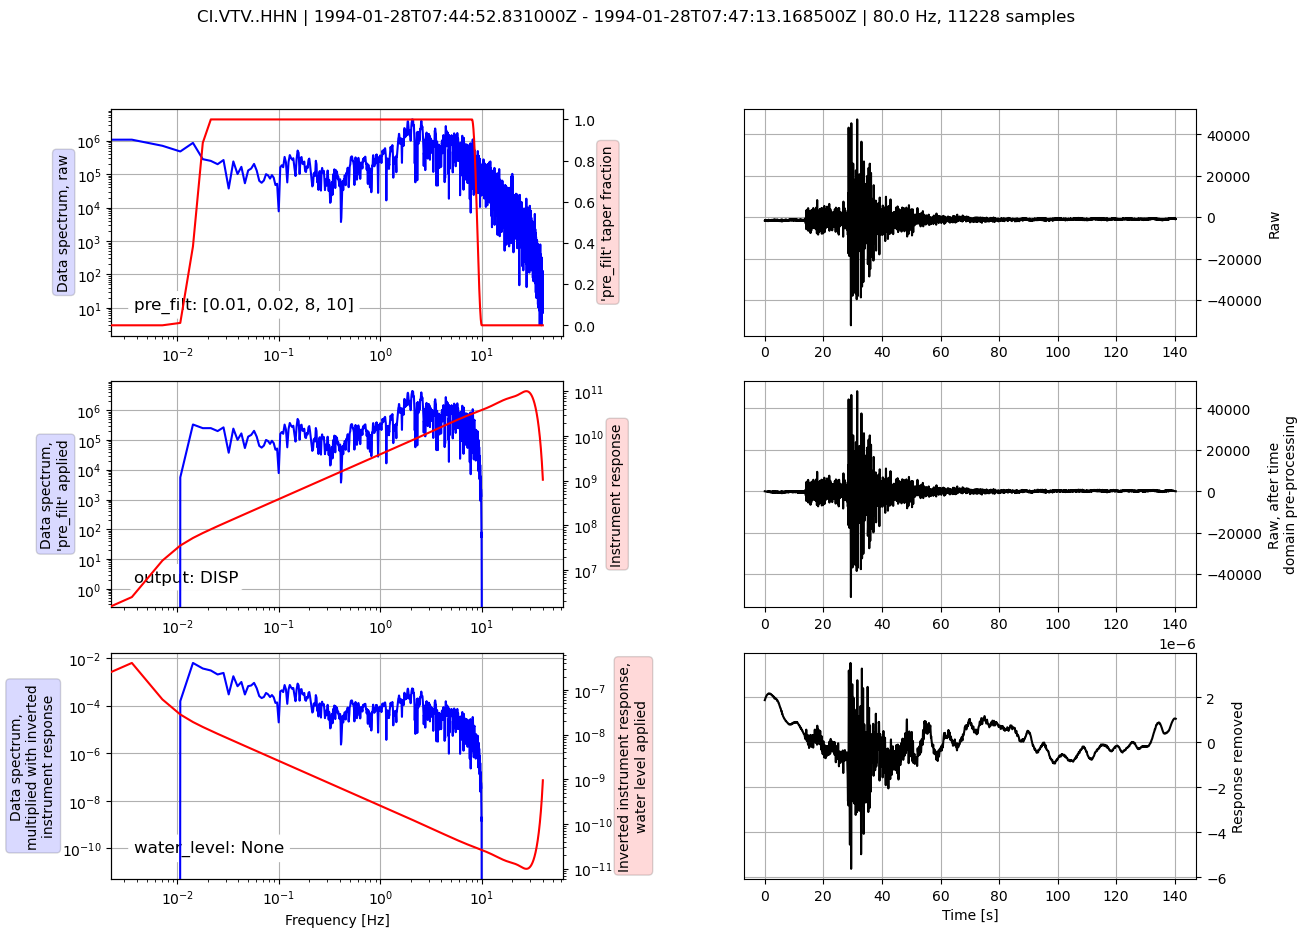

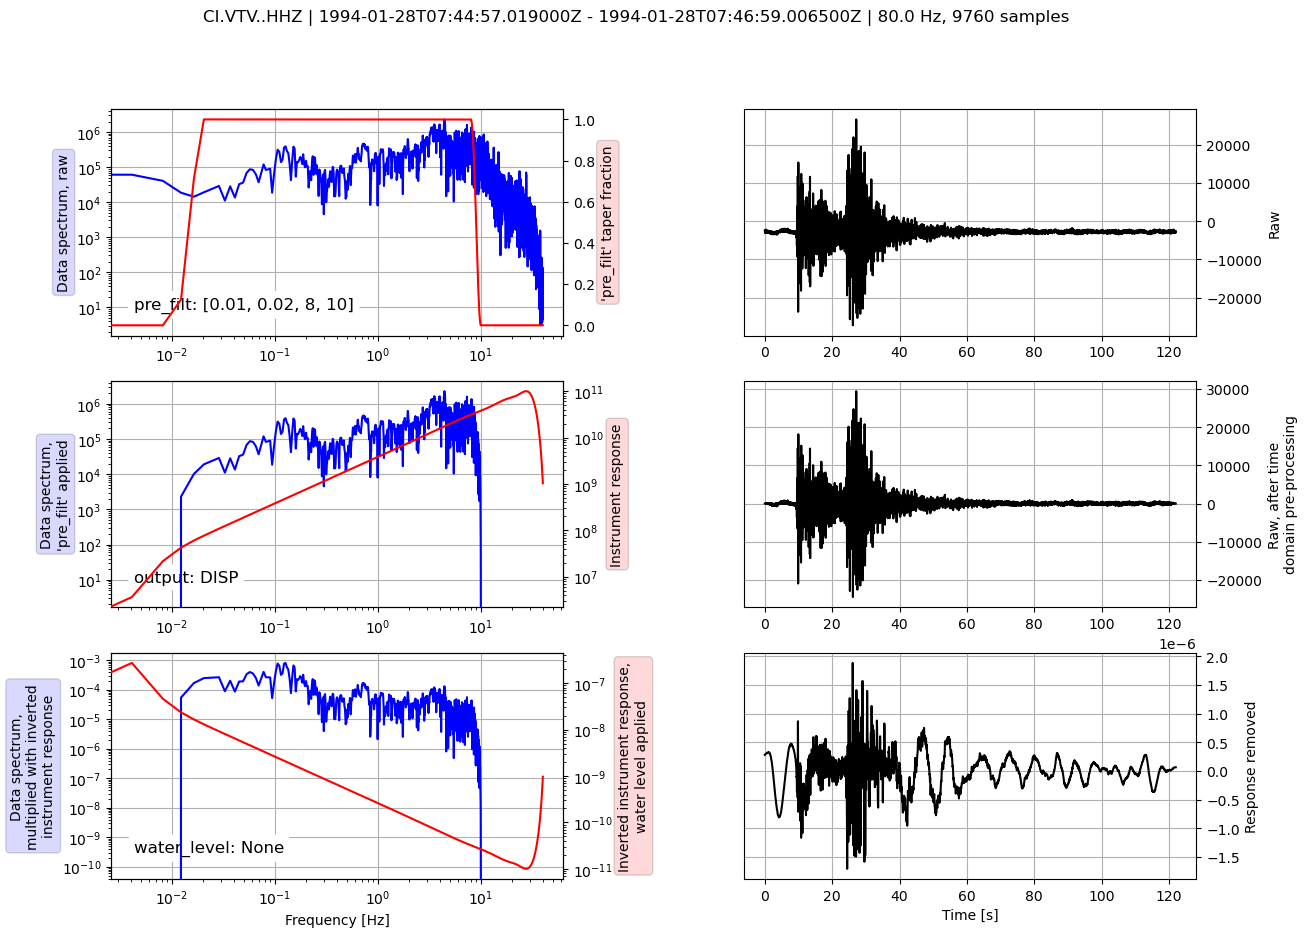

In [144]:
pre_filt = (0.01, 0.02, 8.0, 10.0)
for tr in streams[event_id]:
    tr.remove_response(inventory=inv, output="DISP", pre_filt=pre_filt,
                       plot=True, water_level=None)
streams[event_id].plot();

In [146]:
streams[event_id]

6 Trace(s) in Stream:
CI.VTV..BHE | 1994-01-28T07:43:03.917002Z - 1994-01-28T07:49:42.667002Z | 20.0 Hz, 7976 samples
CI.VTV..BHN | 1994-01-28T07:44:04.417002Z - 1994-01-28T07:49:03.617002Z | 20.0 Hz, 5985 samples
CI.VTV..BHZ | 1994-01-28T07:44:03.217001Z - 1994-01-28T07:49:15.967001Z | 20.0 Hz, 6256 samples
CI.VTV..HHE | 1994-01-28T07:44:52.581000Z - 1994-01-28T07:47:10.343500Z | 80.0 Hz, 11022 samples
CI.VTV..HHN | 1994-01-28T07:44:52.831000Z - 1994-01-28T07:47:13.168500Z | 80.0 Hz, 11228 samples
CI.VTV..HHZ | 1994-01-28T07:44:57.019000Z - 1994-01-28T07:46:59.006500Z | 80.0 Hz, 9760 samples

In [145]:
#  get the fourier spectrum of the data and look at the frequencies with the most energy, then adjust pre_filt accordingly
